**Goal:** turn raw, unstructured text into numeric features three ways --
handcrafted counts, a bag-of-words matrix, and TF-IDF weights -- and use Unit
III's EDA skills to *verify* that the features carry signal. Pairs with the
concept note
[From Raw Data to Features: Turning Text into Numbers](l10_concept_feature_engineering.qmd).

> This page is the read-only view. To run the lab, open the notebook
> (`l10_lab_text_features_spam.ipynb`) -- in Colab via the badge on the concept
> page, or locally.

## Prerequisites & Setup

Run this first. The dataset is the **SMS Spam Collection**: 5,574 real text
messages labeled `ham` (legitimate) or `spam` (Almeida, Gomez Hidalgo &
Yamakami 2011; UCI Machine Learning Repository id 228, CC BY 4.0). It is
bundled with the course as `data/sms_spam.csv`; the cell falls back to the
UCI download when the notebook runs standalone (for example, a fresh Colab
session).

In [1]:
# Setup: run this cell first (required for Colab -- it resets on open)
%pip install -q pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# SMS Spam Collection -- Almeida, Gomez Hidalgo & Yamakami (2011); UCI id 228; CC BY 4.0
LOCAL = "data/sms_spam.csv"
URL = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"

if os.path.exists(LOCAL):
    sms = pd.read_csv(LOCAL)
else:
    import io, zipfile, urllib.request
    with urllib.request.urlopen(URL) as r:
        z = zipfile.ZipFile(io.BytesIO(r.read()))
    sms = pd.read_table(z.open("SMSSpamCollection"), header=None,
                        names=["label", "message"], quoting=3)

print(sms.shape)

(5574, 2)


<details><summary>Expected Output</summary>

~~~text
(5574, 2)
~~~
</details>

## Step 1: First Look -- What Are We Working With? (Worked)

Two columns only: a label and raw text. Before engineering anything, look at
the data -- the Unit III reflex applies to text too.

In [3]:
print(sms["label"].value_counts())
print()
print("A ham message:")
print(" ", sms.loc[1, "message"])
print()
print("A spam message:")
print(" ", sms.loc[2, "message"])

label
ham     4827
spam     747
Name: count, dtype: int64

A ham message:
  Ok lar... Joking wif u oni...

A spam message:
  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's


<details><summary>Expected Output</summary>

~~~text
label
ham     4827
spam     747
Name: count, dtype: int64

A ham message:
  Ok lar... Joking wif u oni...

A spam message:
  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
~~~
</details>

> **Read it:** 4,827 ham vs 747 spam -- about 13% spam, so the classes are
> *imbalanced*; keep that in mind whenever you compare raw counts between the
> groups. And look at the messages themselves: the ham is short, informal,
> personal. The spam is long, stuffed with digits (a shortcode, a phone
> number, a year) and promotional words. Everything we engineer below is just
> turning that visual impression into numbers.

## Step 2: Handcrafted Features -- One-Line Signals (Worked + Completion)

The concept note's claim: single-number features computed from the raw string
already separate the classes. Let's verify it.

In [4]:
sms["length"] = sms["message"].str.len()
sms["digit_count"] = sms["message"].str.count(r"\d")   # r"\d" matches one digit character

print(sms.groupby("label")[["length", "digit_count"]].mean().round(2))

       length  digit_count
label                     
ham     71.47         0.31
spam   138.68        15.81


<details><summary>Expected Output</summary>

~~~text
       length  digit_count
label                     
ham     71.47         0.31
spam   138.68        15.81
~~~
</details>

> **Read it:** there is the concept note's star number, reproduced by your own
> code: spam averages 15.8 digits per message against 0.31 for ham -- a
> fifty-fold gap. Length nearly doubles (139 vs 71 characters). One line of
> `str.count` per feature, and the classes are already pulling apart.

Your turn -- same move, new signal. Do exclamation marks lean spam-ward too?

In [5]:
# Uncomment and fill the ____ (the pattern is just the exclamation mark itself,
# as a one-character string):
# sms["exclam_count"] = sms["message"].str.count(____)
# print(sms.groupby("label")[["length", "digit_count", "exclam_count"]].mean().round(2))

<details><summary>Expected Output</summary>

~~~text
       length  digit_count  exclam_count
label                                   
ham     71.47         0.31          0.18
spam   138.68        15.81          0.73
~~~
*(Yes -- spam averages four times the exclamation marks of ham (0.73 vs 0.18),
though the gap is far less dramatic than the digit one.)*
</details>

Now picture one of them, with the grouped box plot from L08:

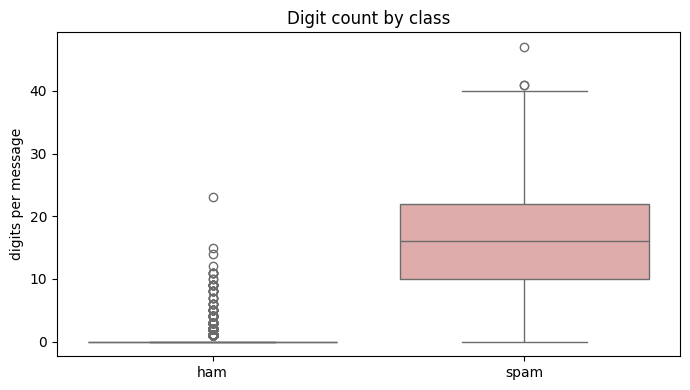

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=sms, x="label", y="digit_count", hue="label", legend=False,
            palette={"ham": "#86b4e3", "spam": "#e8a3a3"}, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("digits per message")
ax.set_title("Digit count by class")
plt.tight_layout()
plt.show()

> **Read it:** the ham box is squashed flat at zero -- the median ham message
> contains no digits at all, and even its 75th percentile is 0 (every visible
> ham point is an "outlier" by the 1.5xIQR rule, which is what that rule looks
> like on extremely skewed data). The spam box spans roughly 10 to 22 digits
> with a median of 16. If you had to separate the classes with a single ruler
> placed on this plot, you could already do a decent job -- that is what a
> useful feature looks like.

## Step 3: Bag of Words -- Let the Text Choose the Columns (Worked + Completion)

Handcrafted features ignore *what the message says*. The bag of words fixes
that: every word in the corpus becomes a column, every message a row of
counts. `CountVectorizer` does tokenization, vocabulary building, and
counting in one call; we drop English stop words and cap the vocabulary at
the 2,000 most frequent terms.

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words="english", max_features=2000)
X_counts = vectorizer.fit_transform(sms["message"])

n_cells = X_counts.shape[0] * X_counts.shape[1]
print(f"Document-term matrix: {X_counts.shape[0]} rows x {X_counts.shape[1]} columns")
print(f"Cells holding a non-zero count: {X_counts.nnz:,} of {n_cells:,} ({X_counts.nnz / n_cells:.2%})")

Document-term matrix: 5574 rows x 2000 columns
Cells holding a non-zero count: 34,548 of 11,148,000 (0.31%)


<details><summary>Expected Output</summary>

~~~text
Document-term matrix: 5574 rows x 2000 columns
Cells holding a non-zero count: 34,548 of 11,148,000 (0.31%)
~~~
</details>

> **Read it:** 5,574 messages times 2,000 vocabulary words is an 11-million-cell
> matrix -- of which 99.69% are zeros. That is why `fit_transform` returns a
> *sparse* matrix: it stores only the 34,548 non-zero counts and their
> positions. Text features are wide and almost empty; the format is built
> for it.

Which words dominate each class? The spam side is worked; ham is yours.

In [8]:
vocab = np.array(vectorizer.get_feature_names_out())
is_spam = (sms["label"] == "spam").values

spam_totals = np.asarray(X_counts[is_spam].sum(axis=0)).ravel()
top_spam = vocab[spam_totals.argsort()[::-1][:10]]
print("Top 10 spam terms:", list(top_spam))

# TODO: uncomment and complete -- same computation for the HAM rows.
# Hint: ~is_spam selects the ham rows.
# ham_totals = np.asarray(X_counts[____].sum(axis=0)).ravel()
# top_ham = vocab[ham_totals.argsort()[::-1][:10]]
# print("Top 10 ham terms: ", list(top_ham))

Top 10 spam terms: ['free', 'txt', 'ur', 'mobile', 'text', 'stop', 'claim', 'reply', 'www', 'prize']


<details><summary>Expected Output</summary>

~~~text
Top 10 spam terms: ['free', 'txt', 'ur', 'mobile', 'text', 'stop', 'claim', 'reply', 'www', 'prize']
Top 10 ham terms:  ['gt', 'lt', 'just', 'ok', 'll', 'ur', 'know', 'good', 'like', 'got']
~~~
</details>

> **Read it:** the spam vocabulary is exactly what you would write on a
> whiteboard if asked to parody spam: free, claim, prize, www, mobile. The ham
> list is casual conversation (just, ok, know, good) -- plus two impostors:
> `gt` and `lt` are not words at all. They are debris from HTML escapes
> (`&gt;` and `&lt;` -- the symbols for "greater than" and "less than") left
> in the raw corpus, and our tokenizer happily counted them. This is the
> concept note's pitfall live: **always inspect your top tokens** -- if they
> are not words, your cleaning has a gap.

## Step 4: TF-IDF -- Promote the Distinctive, Demote the Common (Worked)

Raw counts treat every word equally. TF-IDF re-weights them so words that are
common *everywhere* fade and words *distinctive to a message* stand out.
Compare the two representations on the same spam message from Step 1:

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english", max_features=2000)
X_tfidf = tfidf.fit_transform(sms["message"])

msg_idx = 2
print("The message:")
print(" ", sms.loc[msg_idx, "message"])
print()

counts_row = X_counts[msg_idx].toarray().ravel()
tfidf_row = X_tfidf[msg_idx].toarray().ravel()

top_by_counts = vocab[counts_row.argsort()[::-1][:5]]
top_by_tfidf = vocab[tfidf_row.argsort()[::-1][:5]]
print("Top 5 terms by raw count: ", list(top_by_counts))
print("Top 5 terms by TF-IDF:    ", list(top_by_tfidf))

The message:
  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

Top 5 terms by raw count:  ['fa', 'entry', 'tkts', 'receive', 'apply']
Top 5 terms by TF-IDF:     ['fa', 'entry', '87121', 'tkts', 'cup']


<details><summary>Expected Output</summary>

~~~text
The message:
  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Top 5 terms by raw count:  ['fa', 'entry', 'tkts', 'receive', 'apply']
Top 5 terms by TF-IDF:     ['fa', 'entry', '87121', 'tkts', 'cup']
~~~
</details>

> **Read it:** both rankings agree on "fa" and "entry" (each appears twice in
> the message). The interesting moves are below: TF-IDF *promotes* `87121` --
> the SMS shortcode, which appears almost nowhere else in the corpus and is
> practically a spam fingerprint -- while demoting `receive` and `apply`,
> ordinary words that occur in many messages. That is the inverse-document-
> frequency factor doing its job: distinctiveness over frequency.

## Your Turn (Exercises)

### Exercise 1 -- Invent a feature

Engineer ONE new handcrafted feature not used above, add it as a column, and
show whether it separates ham from spam (a `groupby` mean or a plot, plus one
written sentence). Ideas: count of uppercase letters; count of the word
"call"; longest run of digits; anything you can defend.

> **Hint:** `sms["message"].str.count(r"[A-Z]")` counts uppercase letters --
> a one-line start if nothing else inspires you.

In [10]:
# TODO: your code here

<details><summary>Expected Output (one possible answer)</summary>

~~~text
label
ham      4.10
spam    15.47
Name: upper_count, dtype: float64
~~~
*(Uppercase letters: spam averages about 15.5 capitals per message vs 4.1 for
ham -- SHOUTING is a spam signal. Any feature with a clear by-class gap and an
honest one-sentence read earns full credit.)*
</details>

### Exercise 2 -- Break the vectorizer (on purpose)

Rebuild the document-term matrix with `max_features=500` and **without** stop
word removal. Print the new shape and the new top-10 spam terms. In one
sentence: what happened to the term ranking, and why?

In [11]:
# TODO: your code here

<details><summary>Expected Output (one possible answer -- match the values, not the print format)</summary>

~~~text
shape: (5574, 500)
top spam terms now: ['to', 'call', 'you', 'your', 'free', 'the', 'for', 'now', 'or', 'txt']
~~~
*(Without stop-word removal, the everywhere-words "to", "you", "your", "the"
flood the top of the ranking and bury the informative terms -- this is exactly
the problem stop word lists and TF-IDF exist to fix.)*
</details>

### Exercise 3 -- Written: argue the case

A teammate proposes deleting your handcrafted features (length, digit_count,
exclam_count) because "the TF-IDF matrix already captures everything about
the text." Argue for or against, in 3-4 sentences, using at least one piece
of evidence from this lab.

> **Hint:** can any combination of word columns see *how many digits* a
> message contains, or *how long* it is? What did Step 2 show about how much
> signal those carry?

## Summary

| Move | Key commands | What you learned |
|------|-------------|------------------|
| First look | `value_counts()`, print raw messages | Look at text before engineering; note class imbalance |
| Handcrafted features | `str.len()`, `str.count(r"\d")` | One-line domain insights separate classes (15.8 vs 0.31 digits) |
| Bag of words | `CountVectorizer(stop_words, max_features)` | Text becomes a sparse counts matrix (0.31% non-zero) |
| Inspect tokens | `get_feature_names_out()`, per-class sums | Top terms reveal signal -- and dirty-data artifacts (gt/lt) |
| TF-IDF | `TfidfVectorizer` | Distinctive terms promoted over merely frequent ones |

Next lesson (L11): the matrix you built has 2,000+ columns -- *which of them
actually matter?* That question is feature selection.